In [ ]:
from model import QuadrantSegmentationModel

In [ ]:
quadrant_model = QuadrantSegmentationModel()

In [ ]:
output = quadrant_model.segment_and_overlay("..\data_preprocessed\IBF\images\GT 3_PB090365.JPG")
output[-1]

In [29]:
from pathlib import Path
from typing import Sequence, Dict, Tuple, List, Optional

import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from tqdm.auto import tqdm
from automated_underwater_area_estimation.segmentation_quadrant.model import (
    QuadrantSegmentationModel,
)

EPS = 1e-6

# -------------------------
# I/O: load GT masks from image or .pt
# -------------------------
def load_mask_any(path: str | Path) -> np.ndarray:
    """
    Load binary mask (H,W) as uint8 {0,1}.
    Supports normal image files and .pt (tensor or dict['mask']).
    """
    p = str(path)
    if p.lower().endswith(".pt"):
        import torch as _t
        t = _t.load(p, map_location="cpu")
        if isinstance(t, dict) and "mask" in t:
            t = t["mask"]
        if t.ndim == 3 and t.shape[0] in (1, 3):
            t = t.max(dim=0).values
        m = (t > 0.5).to(_t.uint8).cpu().numpy()
    else:
        m = np.asarray(Image.open(p).convert("L"))
        m = (m > 127).astype(np.uint8)
    if m.ndim == 3:
        m = np.squeeze(m)
    return m.astype(np.uint8)

def _to_bool_t(x: np.ndarray | torch.Tensor, device) -> torch.Tensor:
    if isinstance(x, np.ndarray):
        x = torch.from_numpy(x)
    return (x > 0).to(device=device, dtype=torch.bool)

# -------------------------
# Morphology on GPU
# -------------------------
def _dilate_bool(x_bool: torch.Tensor, k: int) -> torch.Tensor:
    # x_bool: (B,1,H,W) bool -> bool
    pad = k // 2
    return F.max_pool2d(x_bool.float(), kernel_size=k, stride=1, padding=pad) > 0.5

def _erode_bool(x_bool: torch.Tensor, k: int) -> torch.Tensor:
    return ~_dilate_bool(~x_bool, k)

def _edge_from_mask(mask_b: torch.Tensor, k_erode: int = 3) -> torch.Tensor:
    """1-px edge band via XOR(mask, erode(mask)). mask_b: (B,1,H,W) bool."""
    return mask_b ^ _erode_bool(mask_b, k_erode)

# -------------------------
# Metrics from counts
# -------------------------
def _metrics_from_counts(tp: torch.Tensor, fp: torch.Tensor, fn: torch.Tensor) -> Dict[str, float]:
    tp, fp, fn = tp.float(), fp.float(), fn.float()
    precision = (tp / (tp + fp + EPS)).item()
    recall    = (tp / (tp + fn + EPS)).item()
    iou       = (tp / (tp + fp + fn + EPS)).item()
    dice      = (2 * tp / (2 * tp + fp + fn + EPS)).item()
    return {"precision": precision, "recall": recall, "iou": iou, "dice": dice}

# -------------------------
# Main evaluator
# -------------------------
@torch.inference_mode()
def evaluate_quadrant_segmenter(
    image_paths: Sequence[str | Path],
    gt_mask_paths: Sequence[str | Path],
    model: Optional[QuadrantSegmentationModel] = None,
    edge_tol_px: int = 2,     # tolerance for edge matching (in pixels)
    edge_erode_k: int = 3,    # kernel to make 1px-ish edges
) -> Tuple[Dict[str, float], List[Dict[str, float]]]:
    """
    Returns (summary_metrics, per_image_metrics_list).
    Region metrics: IoU, Dice, precision, recall over full masks.
    Edge metrics: same, but computed on thin edges with ±edge_tol_px tolerance.
    """
    assert len(image_paths) == len(gt_mask_paths), "Image/mask list size mismatch."

    # model & device
    model = model or QuadrantSegmentationModel()
    device = model.device

    # totals (region)
    tp_tot = torch.zeros((), device=device)
    fp_tot = torch.zeros((), device=device)
    fn_tot = torch.zeros((), device=device)

    # totals (edge tolerant)
    etp_tot = torch.zeros((), device=device)
    efp_tot = torch.zeros((), device=device)
    efn_tot = torch.zeros((), device=device)

    per_image: List[Dict[str, float]] = []

    for img_p, gt_p in tqdm(zip(image_paths, gt_mask_paths), desc="Segmenting images"):
        # --- load
        pil_img = Image.open(img_p).convert("RGB")
        gt_np   = load_mask_any(gt_p)  # (H,W) {0,1}
        # --- predict
        pred_np = model.segment_image(pil_img)  # (H,W) labels, {0,1}
        if pred_np.ndim == 3:
            pred_np = np.squeeze(pred_np)
        pred_np = (pred_np > 0).astype(np.uint8)

        # ensure same size
        if pred_np.shape != gt_np.shape:
            gt_img = Image.fromarray(gt_np * 255)
            gt_img = gt_img.resize((pil_img.width, pil_img.height), resample=Image.NEAREST)
            gt_np  = (np.asarray(gt_img) > 127).astype(np.uint8)

        # --- to GPU
        pred = _to_bool_t(pred_np, device).unsqueeze(0).unsqueeze(0)  # (1,1,H,W)
        gt   = _to_bool_t(gt_np, device).unsqueeze(0).unsqueeze(0)

        # REGION counts
        tp = torch.count_nonzero(pred & gt)
        fp = torch.count_nonzero(pred & ~gt)
        fn = torch.count_nonzero(~pred & gt)

        # EDGE masks
        pred_edge = _edge_from_mask(pred, k_erode=edge_erode_k)
        gt_edge   = _edge_from_mask(gt,   k_erode=edge_erode_k)

        # Tolerance via dilation (like BFScore-style matching). :contentReference[oaicite:3]{index=3}
        k = 2 * max(edge_tol_px, 0) + 1
        gt_edge_dil   = _dilate_bool(gt_edge, k)
        pred_edge_dil = _dilate_bool(pred_edge, k)

        # tolerant edge TP/FP/FN
        etp = torch.count_nonzero(pred_edge & gt_edge_dil)
        efp = torch.count_nonzero(pred_edge & ~gt_edge_dil)
        efn = torch.count_nonzero(gt_edge   & ~pred_edge_dil)

        # per-image metrics
        reg = _metrics_from_counts(tp, fp, fn)
        edg = _metrics_from_counts(etp, efp, efn)
        per_image.append({
            "image": str(img_p),
            "precision": reg["precision"],
            "recall":    reg["recall"],
            "iou":       reg["iou"],
            "dice":      reg["dice"],
            "edge_precision":   edg["precision"],
            "edge_recall":      edg["recall"],
            "edge_iou":         edg["iou"],
            "edge_dice":        edg["dice"],
        })

        # accumulate
        tp_tot += tp; fp_tot += fp; fn_tot += fn
        etp_tot += etp; efp_tot += efp; efn_tot += efn

        # free per-iter tensors
        del pred, gt, pred_edge, gt_edge, gt_edge_dil, pred_edge_dil

    # dataset-level summary (compute from totals)
    summary = {}
    summary.update({f"region_{k}": v for k, v in _metrics_from_counts(tp_tot, fp_tot, fn_tot).items()})
    summary.update({f"edge_{k}":   v for k, v in _metrics_from_counts(etp_tot, efp_tot, efn_tot).items()})
    summary["N"] = len(image_paths)
    return summary, per_image

# -------------------------
# Example usage
# -------------------------
from pathlib import Path
from typing import Sequence, Tuple, List

# --- Pairing by basename (stem) ---
from pathlib import Path
from typing import Sequence, Tuple, List, Dict

def discover_image_mask_pairs(
    images_dir: Path,
    masks_dir: Path,
    image_exts: Sequence[str] = (".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp", ".webp"),
    mask_exts:  Sequence[str] = (".pt", ".png", ".jpg", ".jpeg", ".tif", ".tiff"),
) -> Tuple[List[Path], List[Path]]:
    """
    Pair images with masks when mask filenames may include an '_improved' suffix.
    - Matches by basename (stem), ignoring a trailing '_improved'/'-improved' on mask files.
    - If both improved and non-improved exist for the same stem, the improved file is used.
    """
    image_exts = {e.lower() for e in image_exts}
    mask_exts  = {e.lower() for e in mask_exts}

    # Index images by lowercase stem
    img_by_stem: Dict[str, Path] = {}
    for p in images_dir.iterdir():
        if p.is_file() and p.suffix.lower() in image_exts:
            img_by_stem[p.stem.lower()] = p

    # Helper to normalize mask stem (strip trailing "_improved" or "-improved")
    def _norm_mask_stem(p: Path) -> tuple[str, bool]:
        s = p.stem.lower()
        improved = False
        for tag in ("_improved", "-improved"):
            if s.endswith(tag):
                s = s[: -len(tag)]
                improved = True
                break
        return s, improved

    # For masks: keep the improved one if both exist
    mask_by_norm_stem: Dict[str, Path] = {}
    improved_flag: Dict[str, bool] = {}
    for p in masks_dir.iterdir():
        if not (p.is_file() and p.suffix.lower() in mask_exts):
            continue
        stem_norm, is_improved = _norm_mask_stem(p)
        # prefer improved masks
        if stem_norm not in mask_by_norm_stem or (is_improved and not improved_flag.get(stem_norm, False)):
            mask_by_norm_stem[stem_norm] = p
            improved_flag[stem_norm] = is_improved

    # Build aligned lists
    common = sorted(set(img_by_stem.keys()) & set(mask_by_norm_stem.keys()))
    imgs   = [img_by_stem[k] for k in common]
    masks  = [mask_by_norm_stem[k] for k in common]

    # Diagnostics
    missing_masks = sorted(set(img_by_stem.keys()) - set(mask_by_norm_stem.keys()))
    missing_imgs  = sorted(set(mask_by_norm_stem.keys()) - set(img_by_stem.keys()))
    if missing_masks:
        print(f"[WARN] {len(missing_masks)} images missing masks (e.g., {missing_masks[:5]})")
    if missing_imgs:
        print(f"[WARN] {len(missing_imgs)} masks missing images (e.g., {missing_imgs[:5]})")

    n_improved_used = sum(improved_flag.get(k, False) for k in common)
    if n_improved_used:
        print(f"[INFO] Using {n_improved_used}/{len(common)} improved masks (preferred when both present).")

    return imgs, masks


    return imgs, masks

if __name__ == "__main__":
    # Provide your own lists (same order)
    images_dir = Path("../data_preprocessed/IBF/images")
    masks_dir  = Path("../data_preprocessed/IBF/improved_masks")
    imgs, gts = discover_image_mask_pairs(images_dir, masks_dir)

    model = QuadrantSegmentationModel()  # will auto-pick device & weights
    summary, per_image = evaluate_quadrant_segmenter(imgs, gts, model, edge_tol_px=2)

    print("SUMMARY:", summary)
    import pandas as pd
    pd.DataFrame(per_image).to_csv("per_image_metrics_original.csv", index=False)


[WARN] 4 images missing masks (e.g., ['zona rehabilitasi air_p9120275', 'zona rehabilitasi air_p9120283', 'zona rehabilitasi air_p9120284', 'zona rehabilitasi air_p9120329'])
[INFO] Using 492/492 improved masks (preferred when both present).


Segmenting images: 0it [00:00, ?it/s]

SUMMARY: {'region_precision': 0.970378041267395, 'region_recall': 0.988804280757904, 'region_iou': 0.9598322510719299, 'region_dice': 0.9795044660568237, 'edge_precision': 0.6348164081573486, 'edge_recall': 0.6276163458824158, 'edge_iou': 0.46112942695617676, 'edge_dice': 0.6311958432197571, 'N': 492}


In [30]:
import pandas as pd

df = pd.read_csv("per_image_metrics_original.csv")

In [31]:
df.select_dtypes(exclude="object").mean()

precision         0.970179
recall            0.988442
iou               0.959291
dice              0.979210
edge_precision    0.635923
edge_recall       0.629227
edge_iou          0.464986
edge_dice         0.632525
dtype: float64

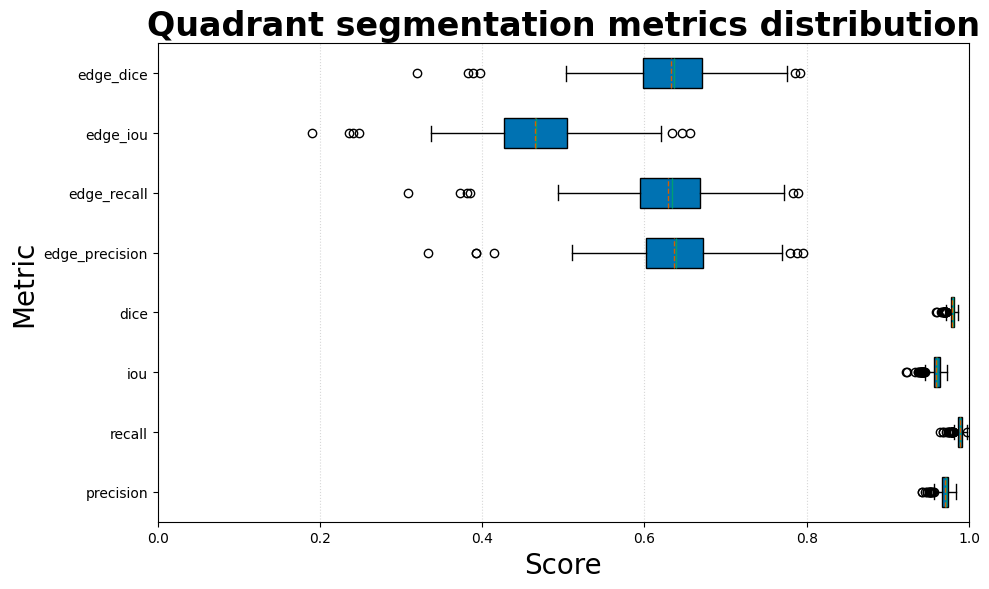

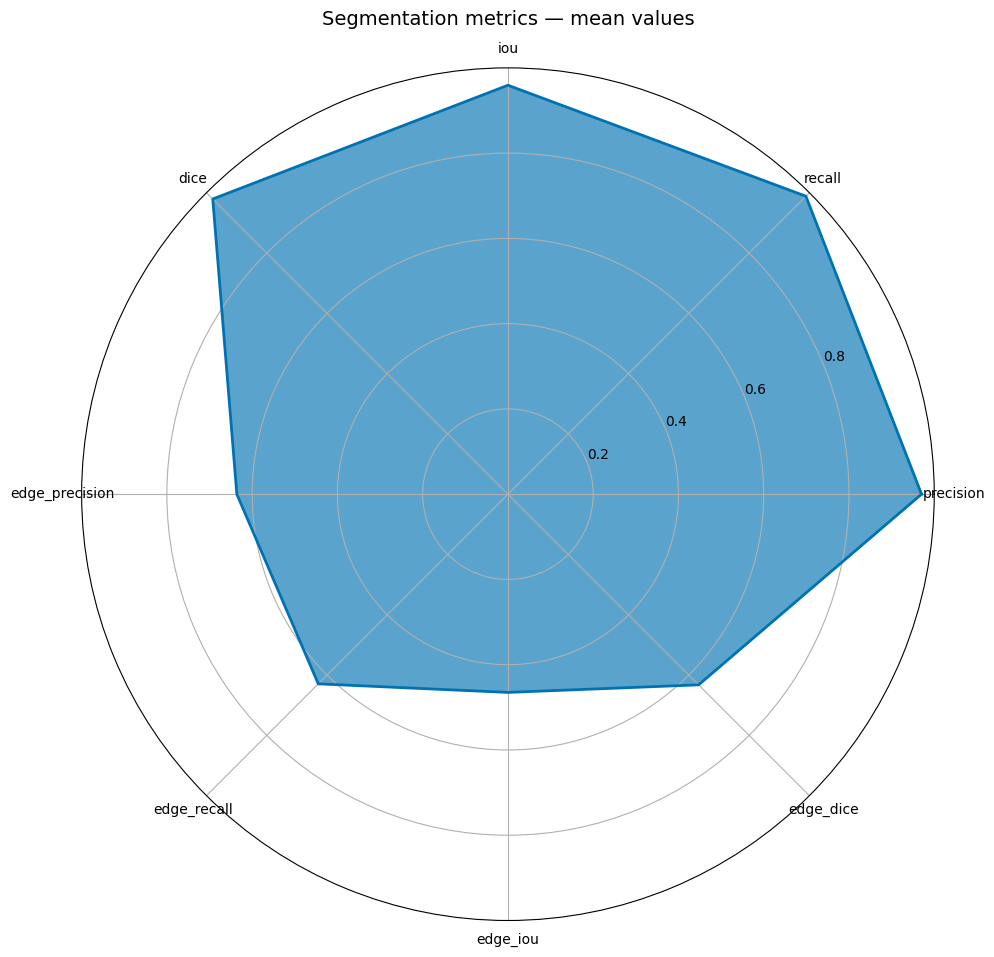

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-colorblind')
# ---------------------------
# Config: which metrics to show
# ---------------------------
METRICS = [
    "precision", "recall", "iou", "dice",
    "edge_precision",   "edge_recall",   "edge_iou",   "edge_dice",
]


# ---------------------------
# Horizontal box plot (metrics on Y, spread along X)
# ---------------------------
def plot_metrics_boxplot(df: pd.DataFrame, metrics=METRICS, title="Quadrant segmentation metrics distribution",
                         save_path=None):
    data = [df[m].astype(float).dropna().to_numpy() for m in metrics]

    fig, ax = plt.subplots(figsize=(10, 6))
    bp = ax.boxplot(
        data,
        orientation="horizontal",
        patch_artist=True,
        showmeans=True,
        meanline=True,
        tick_labels=metrics
    )
    # cosmetics
    ax.set_xlim(0, 1)
    ax.set_xlabel("Score", fontdict={"fontsize": 20})
    ax.set_ylabel("Metric", fontdict={"fontsize": 20})
    ax.set_title(title, fontsize=24, fontweight="bold")
    ax.grid(True, axis="x", linestyle=":", alpha=0.5)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
    return fig, ax

# ---------------------------
# Radar chart for metric means
# ---------------------------
def plot_metrics_radar(df: pd.DataFrame, metrics=METRICS, title="Segmentation metrics — mean values",
                       save_path=None):
    # Compute means
    means = df[metrics].astype(float).mean().to_numpy()

    # Angles for each axis, plus the first one again to close the polygon
    N = len(metrics)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False)
    angles = np.concatenate([angles, angles[:1]])
    values = np.concatenate([means,  means[:1]])

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, polar=True)
    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.65)

    # Axis labels at each angle
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, fontsize=10)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8])
    ax.set_ylim(0, 1)  # metrics are in [0,1]
    ax.set_title(title, fontsize=14, pad=12)

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
    return fig, ax

# ---------------------------
# Example usage
# ---------------------------
# If you have a CSV with per-image metrics:
# df = pd.read_csv("per_image_metrics.csv")

# Or if you already have a DataFrame `per_image_df` from your evaluator:
# df = per_image_df

fig1, ax1 = plot_metrics_boxplot(df, save_path="metrics_boxplot.png")
fig2, ax2 = plot_metrics_radar(df,  save_path="metrics_radar.png")
plt.show()


In [23]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']